/tmp/ipykernel_18567/526619402.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  meses = pd.date_range(



DATASET:
        data    cliente    produto      vendas
0 2020-01-31  Cliente_1  Produto_1   81.440599
1 2020-02-29  Cliente_1  Produto_1  298.022925
2 2020-03-31  Cliente_1  Produto_1  102.613285
3 2020-04-30  Cliente_1  Produto_1  108.639945
4 2020-05-31  Cliente_1  Produto_1   98.866653

MÉTRICAS:
      cliente horizonte         MAE        RMSE        R2
0   Cliente_1     curto  218.837683  265.888903 -2.353964
1   Cliente_1     medio  199.690629  258.505387 -1.832338
2   Cliente_1     longo  237.684714  262.485107 -1.920218
3   Cliente_2     curto  104.688620  139.104771 -1.159476
4   Cliente_2     medio  114.649168  150.959223 -1.810272
5   Cliente_2     longo  118.152479  162.340282 -2.249987
6   Cliente_3     curto   74.611209   94.184097  0.362786
7   Cliente_3     medio  131.952671  156.755358 -0.624783
8   Cliente_3     longo  127.738367  173.107709 -0.981452
9   Cliente_4     curto  100.577967  123.877569  0.437763
10  Cliente_4     medio  123.866763  138.379220  0.255869
1

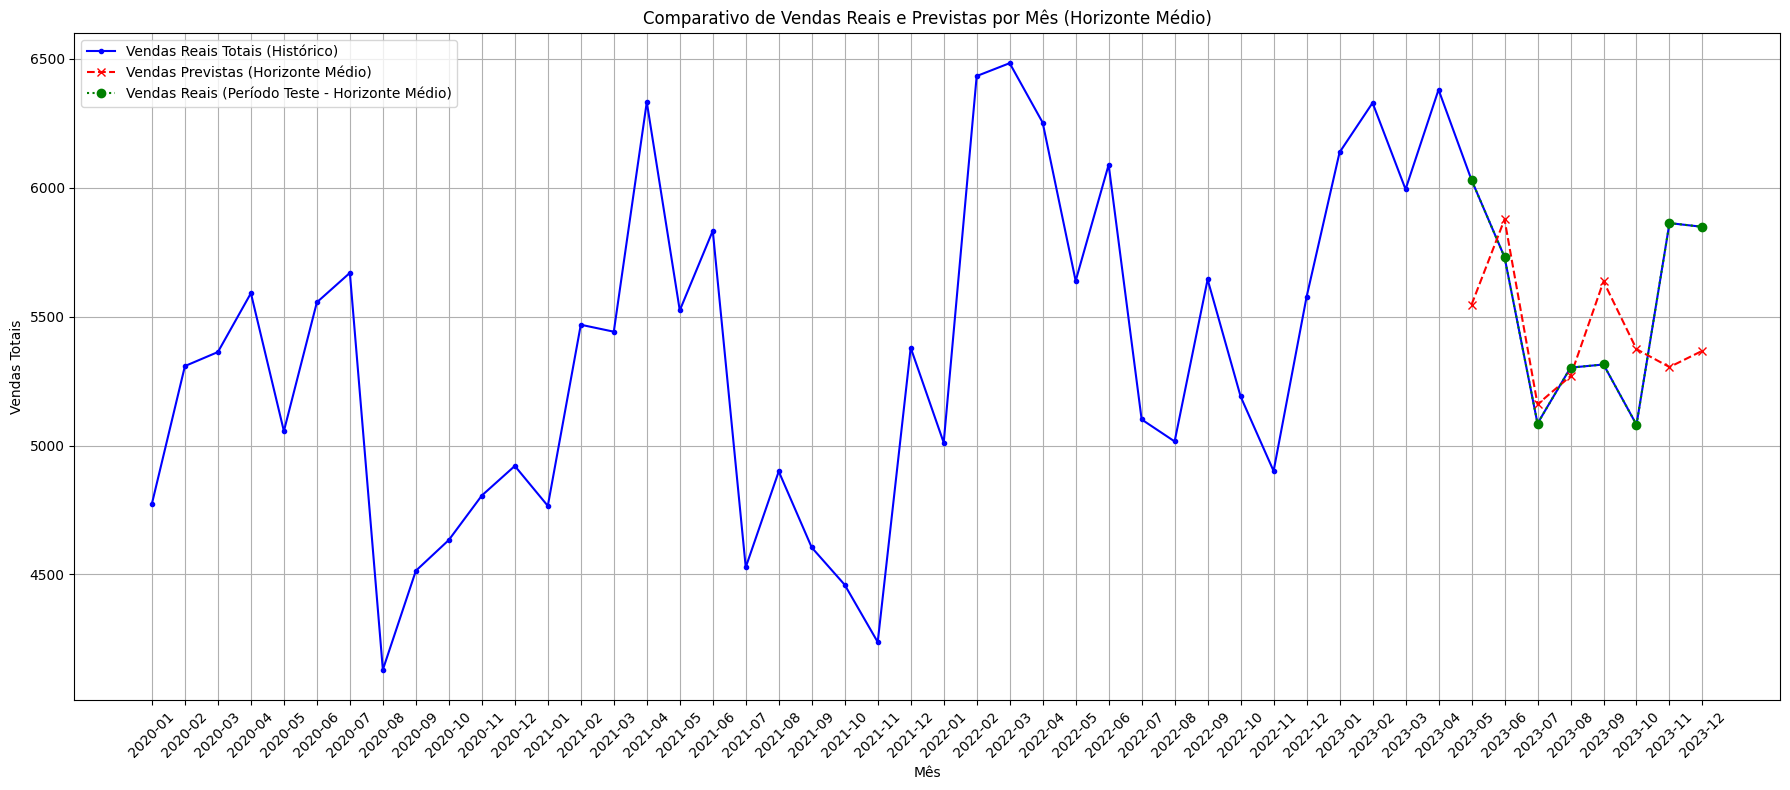


PRECISÃO (Médias para Horizonte 'Medio'):
  MAE Médio: 166.67
  RMSE Médio: 208.34
  R2 Médio: -1.91

PROCESSO FINALIZADO.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# =========================================================
# CONFIGURAÇÕES
# =========================================================

np.random.seed(42)

clientes = [f"Cliente_{i}" for i in range(1, 6)]
produtos = [f"Produto_{i}" for i in range(1, 11)]

meses = pd.date_range(
    start="2020-01-01",
    periods=48,
    freq="M"
)

# =========================================================
# GERAÇÃO DO DATASET
# =========================================================

rows = []

for cliente in clientes:

    cliente_bias = np.random.randint(20, 80)

    for produto in produtos:

        produto_bias = np.random.randint(10, 40)

        tendencia = np.linspace(
            0,
            25,
            len(meses)
        )

        sazonalidade = 15 * np.sin(
            np.linspace(
                0,
                8 * np.pi,
                len(meses)
            )
        )

        ruido = np.random.normal(
            0,
            5,
            len(meses)
        )

        vendas = (
            cliente_bias +
            produto_bias +
            tendencia +
            sazonalidade +
            ruido
        )

        vendas = np.maximum(vendas, 0)

        # OUTLIERS
        outlier_idx = np.random.choice(
            len(meses),
            size=3,
            replace=False
        )

        vendas[outlier_idx] *= np.random.uniform(
            2,
            4
        )

        for i, mes in enumerate(meses):

            rows.append([
                mes,
                cliente,
                produto,
                vendas[i]
            ])

df = pd.DataFrame(
    rows,
    columns=[
        "data",
        "cliente",
        "produto",
        "vendas"
    ]
)

print("\nDATASET:")
print(df.head())

# =========================================================
# FEATURES TEMPORAIS
# =========================================================

def criar_features(df_cliente):

    df_cliente = df_cliente.copy()

    df_cliente["mes"] = (
        df_cliente["data"]
        .dt.month
    )

    df_cliente["ano"] = (
        df_cliente["data"]
        .dt.year
    )

    # LAGS
    df_cliente["lag_1"] = (
        df_cliente["vendas"]
        .shift(1)
    )

    df_cliente["lag_3"] = (
        df_cliente["vendas"]
        .shift(3)
    )

    df_cliente["lag_6"] = (
        df_cliente["vendas"]
        .shift(6)
    )

    # MÉDIAS MÓVEIS
    df_cliente["rolling_mean_3"] = (
        df_cliente["vendas"]
        .rolling(3)
        .mean()
    )

    df_cliente["rolling_mean_6"] = (
        df_cliente["vendas"]
        .rolling(6)
        .mean()
    )

    df_cliente = df_cliente.dropna()

    return df_cliente

# =========================================================
# HORIZONTES
# =========================================================

horizontes = {
    "curto": 1,
    "medio": 3,
    "longo": 6
}

# =========================================================
# TREINAMENTO DOS 15 MODELOS
# =========================================================

modelos = {}

metricas = []

predicoes_finais = []

# List to store all test predictions for plotting
all_test_predictions = []

features = [
    "mes",
    "ano",
    "lag_1",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6"
]

for cliente in clientes:

    # AGREGAÇÃO DAS VENDAS DO CLIENTE
    df_cliente = (
        df[df["cliente"] == cliente]
        .groupby("data")["vendas"]
        .sum()
        .reset_index()
    )

    df_cliente = criar_features(
        df_cliente
    )

    for nome_horizonte, horizonte in horizontes.items():

        # TARGET FUTURO
        df_cliente[f"target_{horizonte}"] = (
            df_cliente["vendas"]
            .shift(-horizonte)
        )

        temp = df_cliente.dropna()

        X = temp[features]

        y = temp[f"target_{horizonte}"]

        split = int(
            len(temp) * 0.8
        )

        X_train = X.iloc[:split]
        X_test = X.iloc[split:]

        y_train = y.iloc[:split]
        y_test = y.iloc[split:]

        # MODELO XGBOOST
        model = XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        # MÉTRICAS
        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        metricas.append({
            "cliente": cliente,
            "horizonte": nome_horizonte,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        modelos[
            (cliente, nome_horizonte)
        ] = model

        # Store test predictions for plotting
        # Dates for the predictions:
        # The 'data' column in temp.iloc[split:] represents the dates of the features used to make the prediction.
        # The predictions are for 'horizonte' months *after* these feature dates.
        dates_of_features_for_test = temp["data"].iloc[split:]
        dates_of_forecasted_sales = [d + pd.DateOffset(months=horizonte) for d in dates_of_features_for_test]
        dates_of_forecasted_sales_period = pd.to_datetime(dates_of_forecasted_sales).to_period("M")

        all_test_predictions.append(pd.DataFrame({
            "data_mes": dates_of_forecasted_sales_period,
            "cliente": cliente,
            "horizonte": nome_horizonte,
            "venda_real_teste": y_test.values,
            "venda_prevista_teste": y_pred
        }))

        # PREVISÃO FUTURA (single point forecast for the very end of the series)
        ultima_linha = X.iloc[[-1]]

        previsao = model.predict(
            ultima_linha
        )[0]

        predicoes_finais.append({
            "cliente": cliente,
            "horizonte": nome_horizonte,
            "previsao_total": previsao
        })

# =========================================================
# MÉTRICAS
# =========================================================

metricas_df = pd.DataFrame(
    metricas
)

print("\nMÉTRICAS:")
print(metricas_df)

# =========================================================
# PARTICIPAÇÃO DOS PRODUTOS
# =========================================================

participacao = (
    df.groupby([
        "cliente",
        "produto"
    ])["vendas"]
    .mean()
    .reset_index()
)

participacao["share"] = (
    participacao
    .groupby("cliente")["vendas"]
    .transform(
        lambda x: x / x.sum()
    )
)

# =========================================================
# REDISTRIBUIÇÃO DAS PREVISÕES
# =========================================================

forecast_produto = []

for pred in predicoes_finais:

    cliente = pred["cliente"]

    horizonte = pred["horizonte"]

    total = pred["previsao_total"]

    temp = participacao[
        participacao["cliente"] == cliente
    ]

    for _, row in temp.iterrows():

        forecast_produto.append({
            "cliente": cliente,
            "produto": row["produto"],
            "horizonte": horizonte,
            "venda_prevista": (
                total * row["share"]
            )
        })

forecast_df = pd.DataFrame(
    forecast_produto
)

#print("\nPREVISÕES:")
#print(forecast_df.head())

# =========================================================
# PLOT: Vendas Reais e Previstas por Mês (Linha)
# =========================================================

# Concatenate all test predictions
all_test_predictions_df = pd.concat(all_test_predictions)

# Aggregate total real sales per month from the original dataset
total_historical_sales = df.groupby(df["data"].dt.to_period("M"))["vendas"].sum()

# Filter for 'medio' horizon and aggregate test predictions by month across all clients
monthly_forecast_data_medio = (
    all_test_predictions_df[all_test_predictions_df["horizonte"] == "medio"]
    .groupby("data_mes")
    [["venda_real_teste", "venda_prevista_teste"]]
    .sum()
)

fig, ax = plt.subplots(figsize=(18, 8))

# Plot historical total real sales
ax.plot(
    total_historical_sales.index.astype(str),
    total_historical_sales.values,
    label='Vendas Reais Totais (Histórico)',
    color='blue',
    linestyle='-',
    marker='.'
)

# Plot forecasted sales for the 'medio' horizon test period
ax.plot(
    monthly_forecast_data_medio.index.astype(str),
    monthly_forecast_data_medio["venda_prevista_teste"].values,
    label='Vendas Previstas (Horizonte Médio)',
    color='red',
    linestyle='--',
    marker='x'
)

# Overlay actual sales during the test period for 'medio' horizon
ax.plot(
    monthly_forecast_data_medio.index.astype(str),
    monthly_forecast_data_medio["venda_real_teste"].values,
    label='Vendas Reais (Período Teste - Horizonte Médio)',
    color='green',
    linestyle=':',
    marker='o'
)

plt.title("Comparativo de Vendas Reais e Previstas por Mês (Horizonte Médio)")
plt.xlabel("Mês")
plt.ylabel("Vendas Totais")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# PRECISÃO DOS MODELOS
# =========================================================

print("\nPRECISÃO (Médias para Horizonte 'Medio'):")
medio_metrics = metricas_df[metricas_df['horizonte'] == 'medio']
print(f"  MAE Médio: {medio_metrics['MAE'].mean():.2f}")
print(f"  RMSE Médio: {medio_metrics['RMSE'].mean():.2f}")
print(f"  R2 Médio: {medio_metrics['R2'].mean():.2f}")

print("\nPROCESSO FINALIZADO.")